### Übung 3 - Daten II

#### Aufgabe 1 - Verkaufszahlen erhöhen mit dem Will-Rogers-Phänomen (5)

Einen (leider mittlerweile) bekannten Trick erfolgreicher Verkaufsleiter
können Sie hier finden:

Der Regionsleiter der Region _Südhessen/Stadt_ eines Pharmaunternehmens
soll nach der Kündigung eines Kollegen die benachbarte Region _Südhessen/Land_
mit übernehmen. Natürlich sind die Umsätze in den ländlichen Regionen
kleiner als in der Stadt. Er will aber seinen Vorgesetzten zeigen,
dass er sofort die Zahlen erhöhen kann. Die Umsätze der Verschreibungen
in den Bezirken sind in der Tabelle _pharma.txt_ gespeichert.

Als erfahrener Vertriebsmann weiß er was zu tun ist: Er erkennt, dass
der Main-Taunus-Kreis in der falschen Region ist und legt ihn zum
Beginn des zweiten Quartals in die ländliche Region.


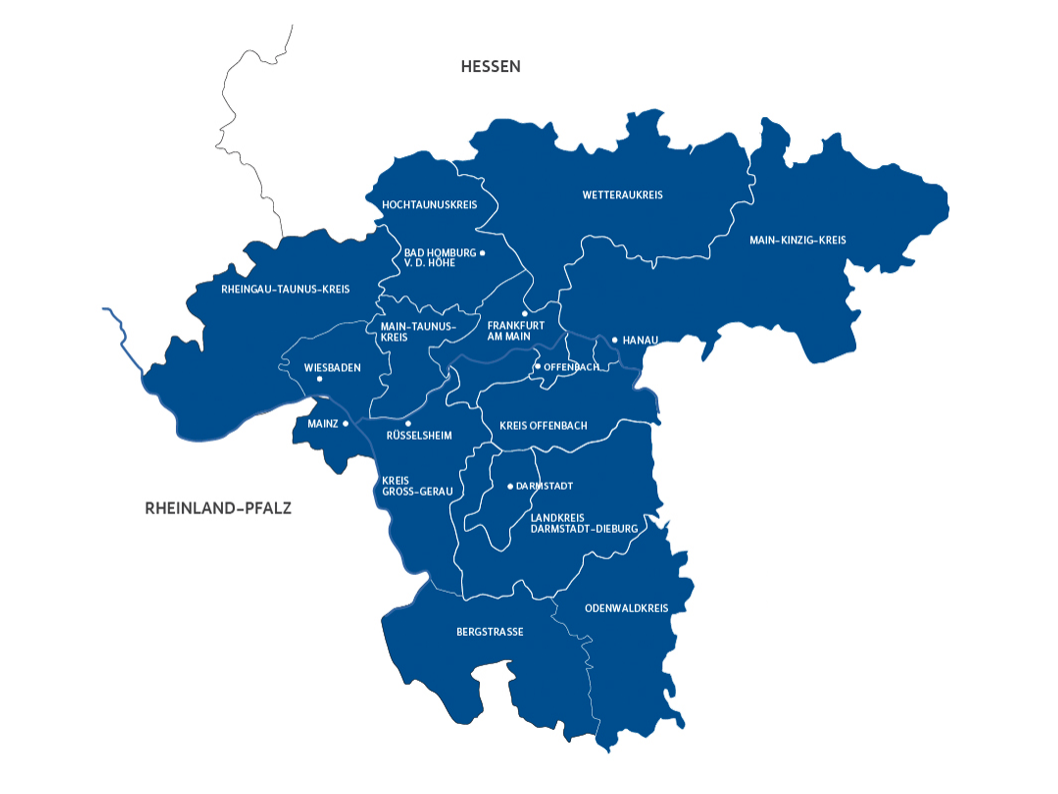

* Berechnen Sie die durchschnittlichen Verschreibungen pro Arzt einzeln in beiden Regionen, jeweils in Q1 vor und in Q2 nach der Umlegung.
* Berechnen Sie die die durchschnittlichen Verschreibungen pro Arzt in beiden Quartalen über alle Bezirke gemeinsam.
 * Erklären Sie den Effekt!

Tipp: `groupby`

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib
import numpy as np

pharma = pd.read_csv("pharma.txt", sep="\t")
pharma

,Bezirk,Region,10000EURproArztinQ1,10000EURproArztinQ2
0,Rheingau-Taunus-Kreis,Land,0.5,0.4
1,Hochtaunuskreis,Land,0.2,0.2
2,Wetteraukreis,Land,1.1,1.2
3,Main-Kinzig-Kreis,Land,0.7,0.5
4,KreisOffenbach,Land,0.5,0.6
5,LandkreisDarmstadt-Dieburg,Land,1.3,1.3
6,Odenwaldkreis,Land,0.2,0.3
7,Bergstraße,Land,0.5,0.6
8,KreisGroß-Gerau,Land,1.0,0.9
9,Rüsselsheim,Stadt,1.9,2.0


In [28]:

land = pharma[pharma["Region"] == "Land"]
land_means_vorher = land.filter(regex="Q[12]").mean()
stadt = pharma[pharma["Region"] == "Stadt"]
stadt_means_vorher = stadt.filter(regex="Q[12]").mean()
mean_gesamt = pharma[["10000EURproArztinQ1", "10000EURproArztinQ2"]].mean()
means = pd.concat(
    [land_means_vorher, stadt_means_vorher, mean_gesamt],
    keys=["Land", "Stadt", "Gesamt"],
)
means

Land    10000EURproArztinQ1    0.666667
        10000EURproArztinQ2    0.666667
Stadt   10000EURproArztinQ1    1.850000
        10000EURproArztinQ2    1.850000
Gesamt  10000EURproArztinQ1    1.223529
        10000EURproArztinQ2    1.223529
dtype: float64

In [29]:
pharma.loc[pharma["Bezirk"] == "Main-Taunus-Kreis", "Region"] = "Land"
land = pharma[pharma["Region"] == "Land"]
land_means_vorher = land.filter(regex="Q[12]").mean()
stadt = pharma[pharma["Region"] == "Stadt"]
stadt_means_vorher = stadt.filter(regex="Q[12]").mean()
mean_gesamt = pharma[["10000EURproArztinQ1", "10000EURproArztinQ2"]].mean()
means = pd.concat(
    [land_means_vorher, stadt_means_vorher, mean_gesamt],
    keys=["Land", "Stadt", "Gesamt"],
)
means

Land    10000EURproArztinQ1    0.730000
        10000EURproArztinQ2    0.730000
Stadt   10000EURproArztinQ1    1.928571
        10000EURproArztinQ2    1.928571
Gesamt  10000EURproArztinQ1    1.223529
        10000EURproArztinQ2    1.223529
dtype: float64

#### Aufgabe 2 - Ein Raucherleben (5)
Eine Studie untersucht die Überlebenschancen von Rauchern und Nichtrauchern.
Dazu wurden Raucher und Nichtraucher erfasst und 20 Jahre später überprüft
ob diese noch leben. Die Ergebnisse sind in der Tabelle wiedergegeben:

Tabelle 1: Altersgruppe 55 bis 64 Jahre

|                       | Raucher | Nichtraucher |
|-----------------------|---------|--------------|
| **Anzahl**            | 115     | 121          |
| **Überlebende nach 20 Jahren** | 64      | 81           |

Tabelle 2: Altersgruppe 65 bis 74 Jahre

|                       | Raucher | Nichtraucher |
|-----------------------|---------|--------------|
| **Anzahl**            | 36      | 129          |
| **Überlebende nach 20 Jahren** | 7       | 28           |

* Berechnen Sie für jede Altersgruppe die Überlebenswahrscheinlichkeit für Raucher und Nichtraucher.
* Berechnen Sie die Überlebenswahrscheinlichkeit für Raucher und Nichtraucher in der Gesamtgruppe.
* Versuchen sie die Ergebnisse zu erklären!

#### Aufgabe 3  (10)

Laden Sie den Datensatz _wine_final.txt_ aus Moodle und verschaffen Sie sich einen Überblick über die Daten. Der Datensatz
enthält Analysenergebnisse von Weinen, eines Weinbaugebiets. Als Klassen sind verschiedene Weingüter
codiert, die jeweils unterschiedliche Rebsorten anbauen.
Der Datensatz enthält eine Probe mit unbekannter Herkunft. Ziel ist es, den unbekannten Wein korrekt zuzuordnen.

__a)__ Lesen Sie den Datensatz in Python ein

__b)__ Nach welchen Merkmalen kann man die Weingüter am besten separieren (Tipp: `pairplot`)

__c)__ Normalisieren Sie die Daten mit dem `StandardScaler`. Was macht der `StandardScaler`? Was müssen Sie im Vorfeld eventuell beachten, und warum?

__d)__ Führen Sie eine Dimensionsreduktion mittels PCA auf den Daten aus und visualisieren Sie die Daten in einem 2 D oder 3 D Scatterplot. Färben Sie die Punkte nach den Weingütern (Tipp: seaborn). Schreiben Sie den Anteil an erklärter Varianz mit an die Achsen. 

__e)__ Welche Attribute haben jeweils einen großen Einfluss auf die ersten zwei Hauptkomponenten? Gibt es Überlappungen mit den Attributen, die Sie in b) identifiziert haben?

__f)__ Visualisieren Sie den Anteil an erklärter Varianz je Hauptkomponente und erklären Sie den Plot.

__g)__ Versuchen Sie durch Visualisierung die unbekannte Probe einem Weingut zuzuordnen.